Entropia da classe: 1.0
-----------------------------------------------------------------------------------------------
Atributo                          Entropia Padrão   Entropia Condicional    Ganho de Informação
-----------------------------------------------------------------------------------------------
V0001                                      3.6764                 0.9869                 0.0131
V0026                                      0.7918                 0.9918                 0.0082
B001                                       1.1558                 0.9995                 0.0005
C009                                       1.4420                 0.9985                 0.0015
N016                                       1.4112                 0.9592                 0.0408
P00104                                     5.8077                 0.9457                 0.0543
P00404                                     5.0679                 0.9671                 0.0329
P01101          

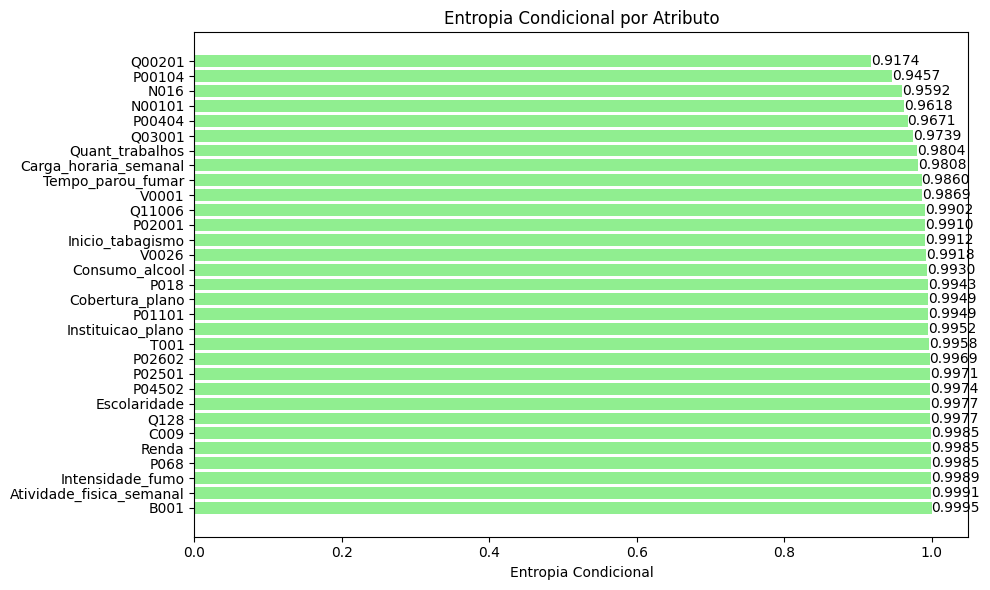


Atributos ordenados por ganho de informação:
---------------------------------------------------
Atributo                        Ganho de Informação
---------------------------------------------------
Q00201                                       0.0826
P00104                                       0.0543
N016                                         0.0408
N00101                                       0.0382
P00404                                       0.0329
Q03001                                       0.0261
Quant_trabalhos                              0.0196
Carga_horaria_semanal                        0.0192
Tempo_parou_fumar                            0.0140
V0001                                        0.0131
Q11006                                       0.0098
P02001                                       0.0090
Inicio_tabagismo                             0.0088
V0026                                        0.0082
Consumo_alcool                               0.0070
P018              

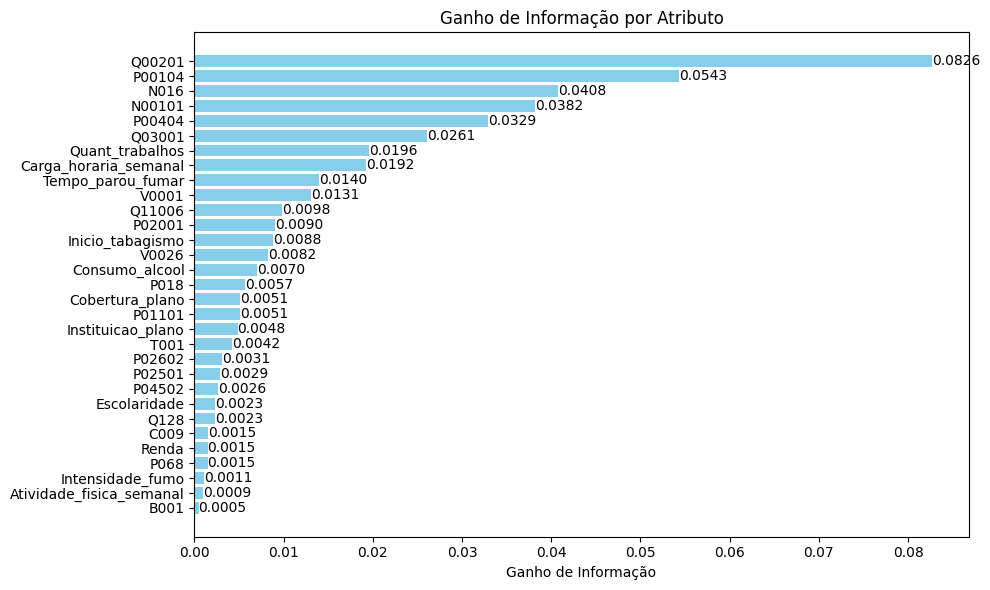

In [2]:
import pandas as pd
from scipy.stats import entropy
import matplotlib.pyplot as plt

# base = pd.read_csv("../Bases/Criados/5_base_codificada.csv")
base = pd.read_csv("../Bases/Criados/Treino_Teste/random.csv")
classe = "Q06306"

def entropia_padrao(column):
    prob = column.value_counts(normalize=True)
    return entropy(prob, base=2)

def entropia_condicional(atributo, classe):
    df = pd.concat([atributo, classe], axis=1)
    valores = atributo.unique()
    total = len(atributo)
    entropia_cond = 0.0
    for valor in valores:
        subset = df[df[atributo.name] == valor][classe.name]
        proporcao = len(subset) / total
        entropia_subset = entropia_padrao(subset)
        entropia_cond += proporcao * entropia_subset
    return entropia_cond

entropia_classe = entropia_padrao(base[classe])
print(f"Entropia da classe: {round(entropia_classe, 4)}")
print("-" * 95)

ganhos = {}
entropias_cond = {}

print(f"{'Atributo':<30} {'Entropia Padrão':>18} {'Entropia Condicional':>22} {'Ganho de Informação':>22}")
print("-" * 95)

for atributo in base.columns:
    if atributo == classe:
        continue
    entropia_atr = entropia_padrao(base[atributo])
    entropia_cond = entropia_condicional(base[atributo], base[classe])
    ganho = entropia_classe - entropia_cond
    ganhos[atributo] = ganho
    entropias_cond[atributo] = entropia_cond
    print(f"{atributo:<30} {entropia_atr:>18.4f} {entropia_cond:>22.4f} {ganho:>22.4f}")

# Ordena as entropias condicionais
entropias_cond_ordenadas = sorted(entropias_cond.items(), key=lambda x: x[1])

# --- Gráfico de Entropia Condicional ---
plt.figure(figsize=(10, 6))
atributos_cond = [item[0] for item in entropias_cond_ordenadas]
valores_cond = [item[1] for item in entropias_cond_ordenadas]

bars = plt.barh(atributos_cond, valores_cond, color='lightgreen')
plt.xlabel('Entropia Condicional')
plt.title('Entropia Condicional por Atributo')

# Adicionando os valores nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2,
             f'{width:.4f}', va='center', ha='left')

plt.gca().invert_yaxis()  # Coloca o menor no topo
plt.tight_layout()
plt.show()

# Ordena os ganhos
ganhos_ordenados = sorted(ganhos.items(), key=lambda x: x[1], reverse=True)

print("\nAtributos ordenados por ganho de informação:")
print("-" * 51)
print(f"{'Atributo':<30} {'Ganho de Informação':>20}")
print("-" * 51)

for atributo, ganho in ganhos_ordenados:
    print(f"{atributo:<30} {ganho:>20.4f}")

# --- Gráfico de Ganho de Informação ---
plt.figure(figsize=(10, 6))
atributos_ganho = [item[0] for item in ganhos_ordenados]
valores_ganho = [item[1] for item in ganhos_ordenados]

bars = plt.barh(atributos_ganho, valores_ganho, color='skyblue')
plt.xlabel('Ganho de Informação')
plt.title('Ganho de Informação por Atributo')

# Adicionando os valores nas barras
for bar in bars:
    width = bar.get_width()
    plt.text(width, bar.get_y() + bar.get_height() / 2,
             f'{width:.4f}', va='center', ha='left')

plt.gca().invert_yaxis()  # Coloca o maior no topo
plt.tight_layout()
plt.show()